In [1]:
import slsim.Sources as sources
import slsim.Pipelines as pipelines
import slsim.Deflectors as deflectors

from slsim.Lenses.lens_pop import LensPop
from slsim.Lenses.lens import Lens

from slsim.Plots.lens_plots import LensingPlots

import numpy as np
import matplotlib.pyplot as plt
from astropy.units import Quantity
from astropy.cosmology import FlatLambdaCDM
from astropy.table import Table

from lenstronomy.LensModel.lens_model_extensions import LensModelExtensions
import corner

from time import time

import warnings
warnings.filterwarnings('ignore')

from slsim.Pipelines.sl_hammocks_pipeline import SLHammocksPipeline

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-072 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-073
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


In [2]:
#%config InlineBackend.figure_format = 'svg'
plt.rcParams['figure.dpi'] = 300
#np.random.seed(1)

In [3]:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3, Ob0=0.05)

sky_area_deflector = Quantity(value=1, unit="deg2")
sky_area = Quantity(value=1, unit="deg2")

kwargs_deflector_cut = {"band": "g", "band_max": 27, "z_min": 0.01, "z_max": 2.0}
kwargs_source_cut = {"band": "g", "band_max": 27, "z_min": 0.1, "z_max": 5.0}

galaxy_simulation_pipeline = pipelines.SkyPyPipeline(
    skypy_config=None,
    sky_area=sky_area,
    filters=None,
)

#Use both red and blue galaxies as source / field galaxies
source_galaxies = sources.Galaxies(
    galaxy_list=galaxy_simulation_pipeline.all_galaxies,
    kwargs_cut=kwargs_source_cut,
    cosmo=cosmo,
    sky_area=sky_area,
    catalog_type="skypy",
)

In [4]:
halo_galaxy_pipeline = SLHammocksPipeline(
    slhammocks_config=None,
    sky_area=sky_area_deflector,
    cosmo=cosmo,
    z_min=0.01,
    z_max=2,
    loghm_min=14,
    loghm_max=16,
)

lens_galaxies = deflectors.CompoundLensHalosGalaxies(
    halo_galaxy_list=halo_galaxy_pipeline.halo_galaxies,
    kwargs_cut=kwargs_deflector_cut,
    kwargs_mass2light={},
    cosmo=cosmo,
    sky_area=sky_area_deflector,
)

In [5]:
def debug_plot_objects(lens_cluster_class: Lens, ax):
    """
    Plot locations of source galaxies, deflector galaxies, and field galaxies in the source plane. Expects the deflector to be a cluster.

    :param lens_cluster_class: slsim.Lenses.Lens
    :param ax: matplotlib.axes.Axes
    """
    source_class = lens_cluster_class._source
    field_class = lens_cluster_class._field_galaxies
    deflector = lens_cluster_class.deflector._deflector

    ax.plot([s.deflector_center[0] for s in deflector._subhalos], [s.deflector_center[1] for s in deflector._subhalos], "o", label="deflectors", alpha=0.5, color="red")
    ax.plot([s.extended_source_position[0] for s in field_class], [s.extended_source_position[1] for s in field_class], "o", label="field galaxies", alpha=0.5, color="green")
    ax.plot([s.extended_source_position[0] for s in source_class], [s.extended_source_position[1] for s in source_class], "o", label="sources", alpha=0.5, color="blue")

def debug_plot_source_position_shift(lens_cluster_class: Lens, ax):
    """
    Plots the image position shift of sources. Expects the deflector to be a cluster.

    :param lens_cluster_class: slsim.Lenses.Lens
    :param ax: matplotlib.axes.Axes
    """
    source_class = lens_cluster_class._source
    image_positions = lens_cluster_class.extended_source_image_positions
    
    multi_imaged = 0
    for i in range(len(source_class)):
        if len(image_positions[i][0]) <= 1:
            color = "pink" 
            alpha = 0.5
            lw = 0.5
        else:
            colors = "cmyrgb"
            color = colors[multi_imaged % len(colors)]
            multi_imaged += 1

            alpha = 0.8
            lw = 1.0
            
        for j in range(len(image_positions[i][0])):
            ax.plot([source_class[i].extended_source_position[0], image_positions[i][0][j]], [source_class[i].extended_source_position[1], image_positions[i][1][j]],
                    color=color, alpha=alpha, lw=lw)

def debug_plot_caustics(lens_cluster_class: Lens, ax):
    """
    Plot caustic curves of lens_clusterr_class.

    :param lens_cluster_class: slsim.Lenses.Lens
    :param ax: matplotlib.axes.Axes
    """
    lens_model_object, model_params = lens_cluster_class.deflector_mass_model_lenstronomy()
    lens_model_ext = LensModelExtensions(lens_model_object)
    (_, _, ra_caustic_list, dec_caustic_list) = lens_model_ext.critical_curve_caustics(
        model_params,
        compute_window=160,
        grid_scale=0.5,
    )

    label = "caustics"
    for ra, dec in zip(ra_caustic_list, dec_caustic_list):
        ax.plot(ra, dec, color="green", lw=0.75, label=label)
        label = None

def debug_plot_deflector_mass(lens_cluster_class: Lens, ax):
    deflector = lens_cluster_class.deflector._deflector

    for s in deflector._subhalos:
        if not (-40 < s.deflector_center[0] < 40 and -40 < s.deflector_center[1] < 40):
            continue
        ax.text(s.deflector_center[0], s.deflector_center[1],
                 f"{np.log10(s.stellar_mass):.4g}", fontsize="x-small")

def debug_plot_misc(lens_cluster_class: Lens, ax):
    deflector = lens_cluster_class.deflector._deflector

    #ax.set_title(f"number of members in cluster: {len(deflector._subhalos)}; cluster id: {deflector._subhalos[0]._deflector_dict["cluster_id"]}")
    ax.set_aspect('equal')

    ax.set_xlim(-40, 40)
    ax.set_ylim(-40, 40)

### Draw random cluster-source field lenses with multiply imaged sources

In [6]:
lenspop = LensPop(
    deflector_population=lens_galaxies,
    source_population=source_galaxies,
    cosmo=cosmo,
    sky_area=sky_area,
)

cluster_lens_plot = LensingPlots(lenspop, num_pix=400, coadd_years=10)

kwargs_lens_cut_plot = {
    "min_image_separation": 1.0, #0.8, #2.0,
    "max_image_separation": 100.0,
    #"mag_arc_limit": {"g": 22, "r": 22, "i": 22},
}

saved_renders = {}

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


TIME TO SELECT LENS: 6.659709215164185


ValueError: The length of lens_model_list does not correspond to redshift_list

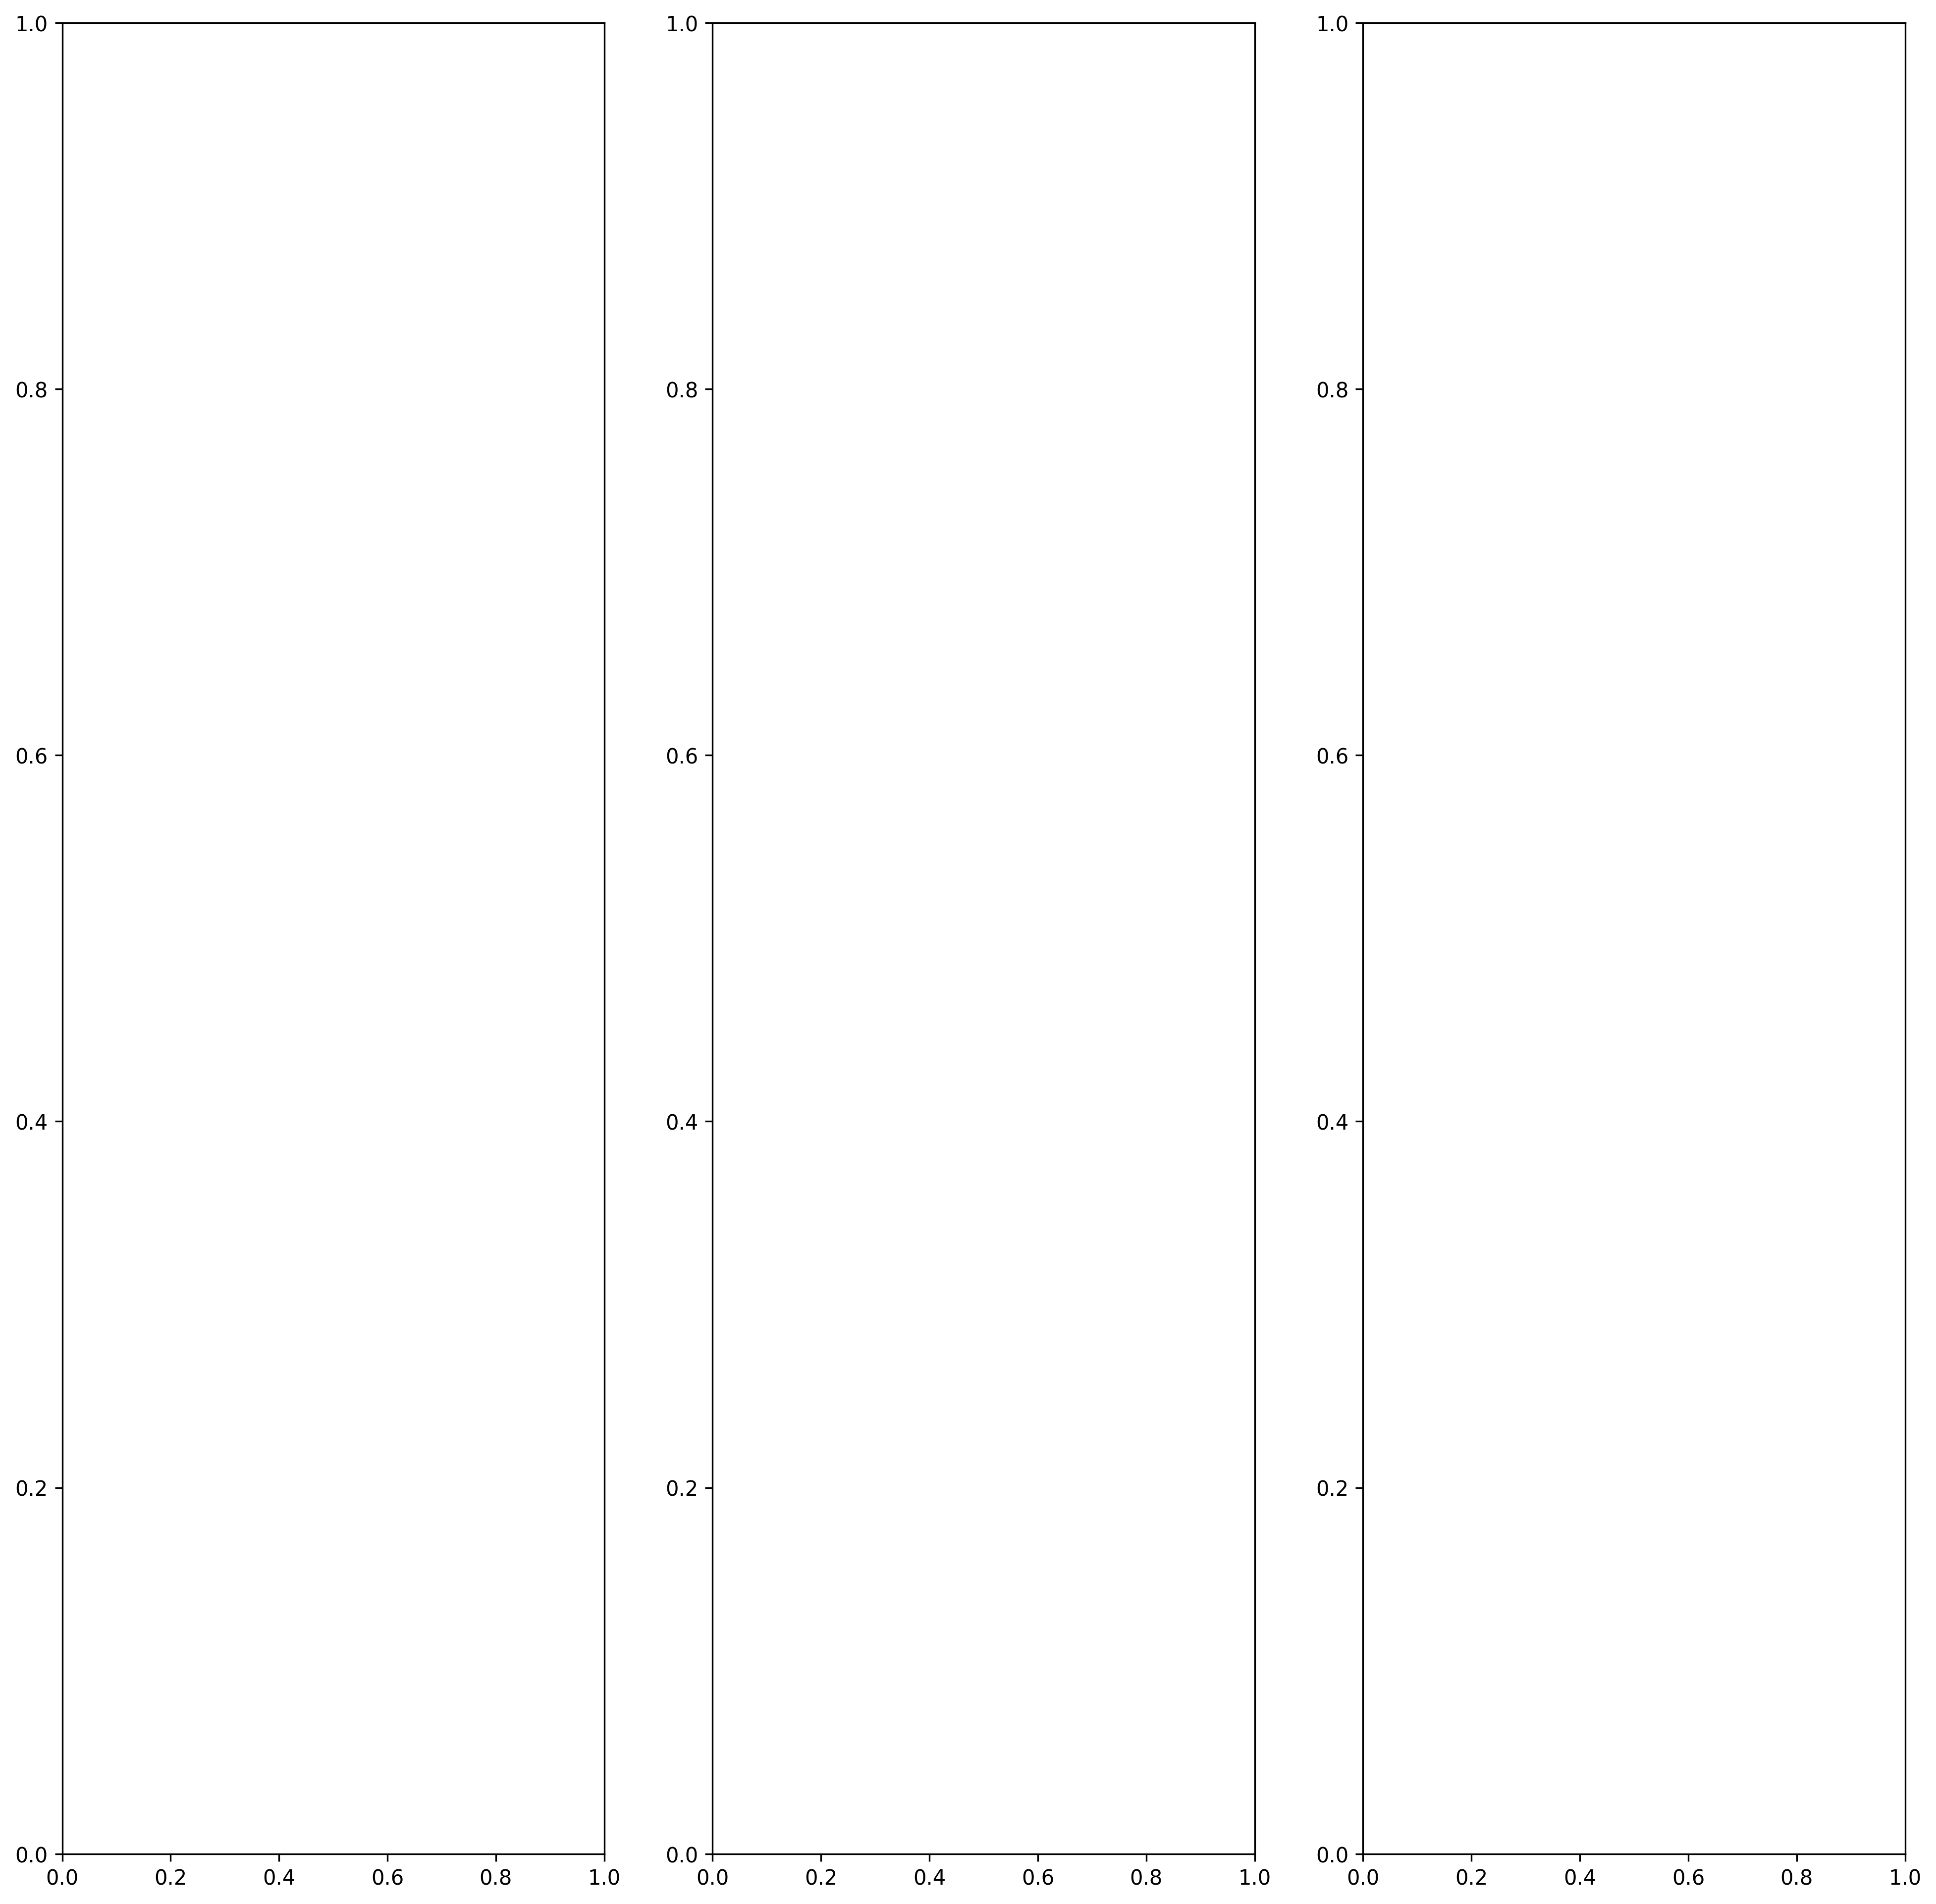

In [ ]:
#for (lens_cluster_class, image_rgb) in saved_renders.keys():
for i in range(10):
    START_TIME = time()
    lens_cluster_class = lenspop.select_lens_at_random(**kwargs_lens_cut_plot) 
    #lens_cluster_class = lenspop.select_lens_at_random_multi_source(Quantity(np.pi * 50 ** 2, "arcsec2"), **kwargs_lens_cut_plot)
    print(f"TIME TO SELECT LENS: {time() - START_TIME}")

    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 16))

    lens_cluster_class.multi_plane = None ################
    
    START_TIME = time()
    image_rgb = cluster_lens_plot.rgb_image(
        lens_class=lens_cluster_class, rgb_band_list=["i", "r", "g"], add_noise=True
    )
    print(f"TIME TO RENDER IMAGE: {time() - START_TIME}")
    

    #debug_plot_caustics(lens_cluster_class, ax1)
    #debug_plot_objects(lens_cluster_class, ax1)
    #debug_plot_deflector_mass(lens_cluster_class, ax1)
    debug_plot_source_position_shift(lens_cluster_class, ax1)
    debug_plot_misc(lens_cluster_class, ax1)
    ax1.legend(fontsize="small")

    ax2.imshow(image_rgb, origin="lower", extent=[-40, 40, -40, 40])
    debug_plot_source_position_shift(lens_cluster_class, ax2)
    debug_plot_misc(lens_cluster_class, ax2)

    ax3.imshow(image_rgb, origin="lower", extent=[-40, 40, -40, 40])
    debug_plot_misc(lens_cluster_class, ax3)

    plt.show()

    #cluster_id = lens_cluster_class.deflector._deflector._subhalos[0]._deflector_dict["cluster_id"]
    #saved_renders[cluster_id] = (lens_cluster_class, image_rgb)

### Statistics

In [ ]:
lens_samples = []

In [26]:
for i in range(1000):
    lens_cluster_class = lenspop.select_lens_at_random_multi_source(**kwargs_lens_cut_plot, return_only_multiply_imaged_sources=True)

    for source in lens_cluster_class._source:
        lens_samples.append([
            lens_cluster_class.deflector_velocity_dispersion(),
            np.log10(lens_cluster_class.deflector_stellar_mass()),
            lens_cluster_class.deflector.redshift,
            source.redshift
        ])

KeyboardInterrupt: 

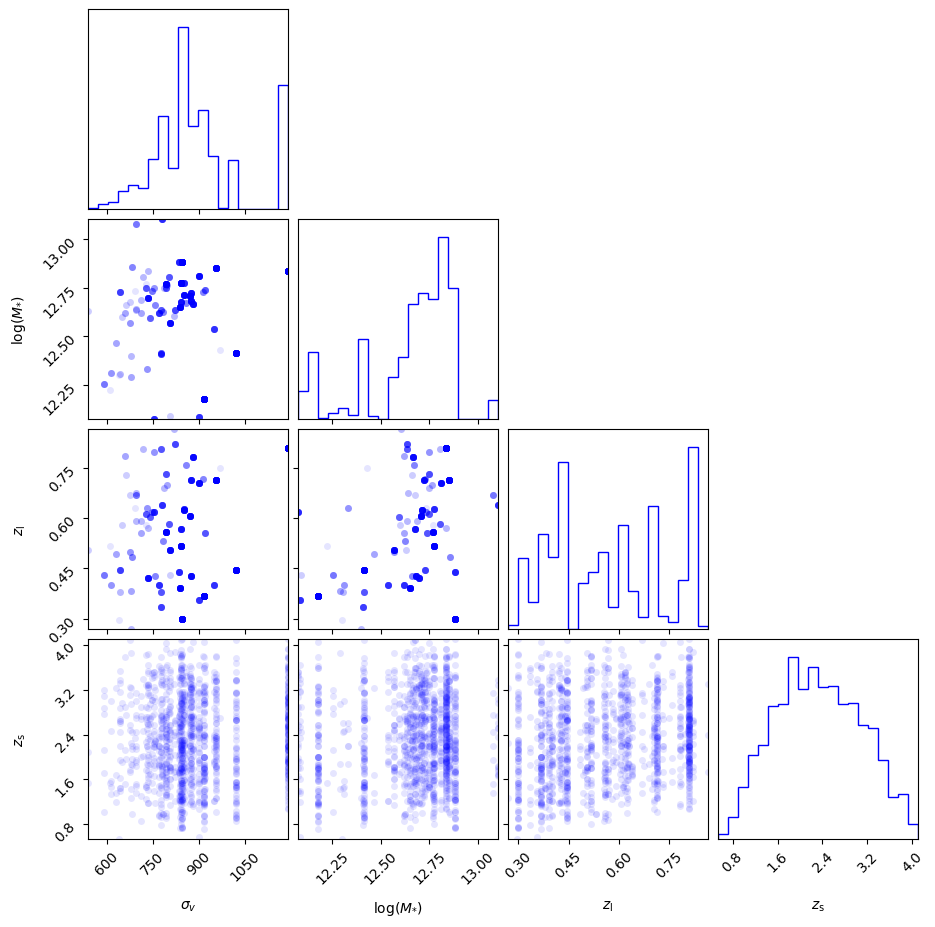

In [27]:
labels = [
    r"$\sigma_v$",
    r"$\log(M_{*})$",
    r"$z_{\rm l}$",
    r"$z_{\rm s}$",
]
hist2dkwargs = {
    "plot_density": False,
    "plot_contours": False,
    "plot_datapoints": True,
    "color": "b",
    "data_kwargs": {"ms": 5},
}
corner.corner(np.array(lens_samples), labels=labels, **hist2dkwargs)
plt.show()

In [15]:
lens_cluster_class.deflector

In [14]:
lens_cluster_class._source